
# End-to-End ML Pipeline on Tesla Sales/Price Data

## Objective
Build a complete Machine Learning pipeline covering:

- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Model Evaluation
- Time Series Forecasting

**Dataset:** Tesla Deliveries & Production Data (2015–2025)


In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error

plt.style.use('default')


## 1. Load Dataset

In [7]:

df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 2. Data Cleaning and Preprocessing

In [8]:

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("\nFinal Shape:", df.shape)


Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows: 0

Final Shape: (2640, 12)


## 3. Exploratory Data Analysis (EDA)

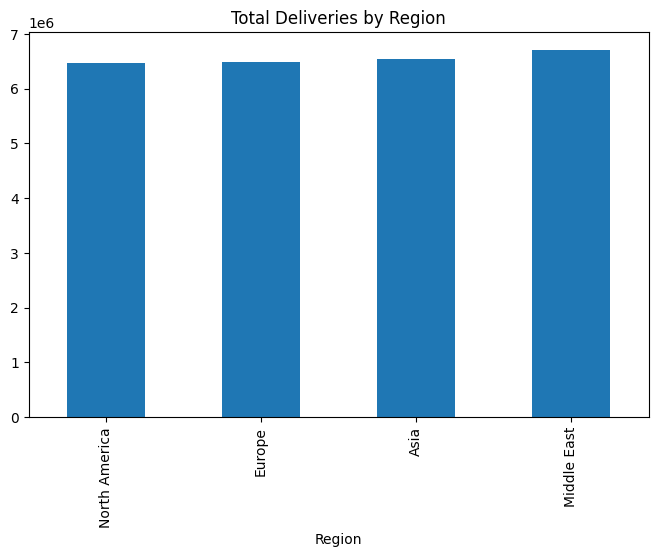

In [9]:

plt.figure(figsize=(8,5))
df.groupby('Region')['Estimated_Deliveries'].sum().sort_values().plot(kind='bar')
plt.title('Total Deliveries by Region')
plt.show()


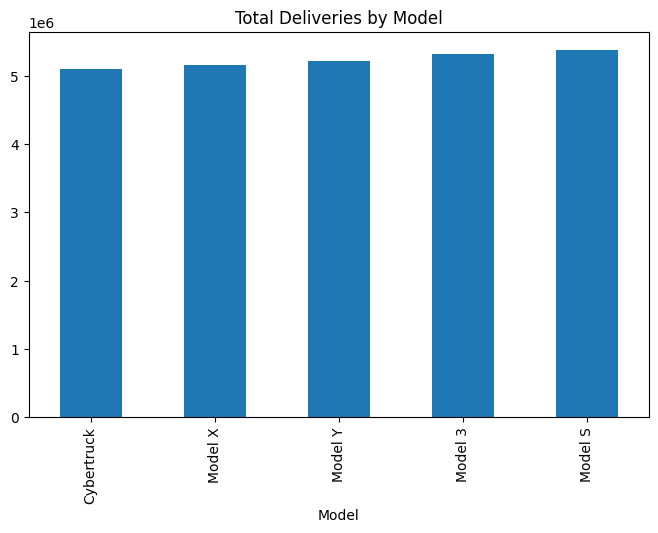

In [10]:

plt.figure(figsize=(8,5))
df.groupby('Model')['Estimated_Deliveries'].sum().sort_values().plot(kind='bar')
plt.title('Total Deliveries by Model')
plt.show()


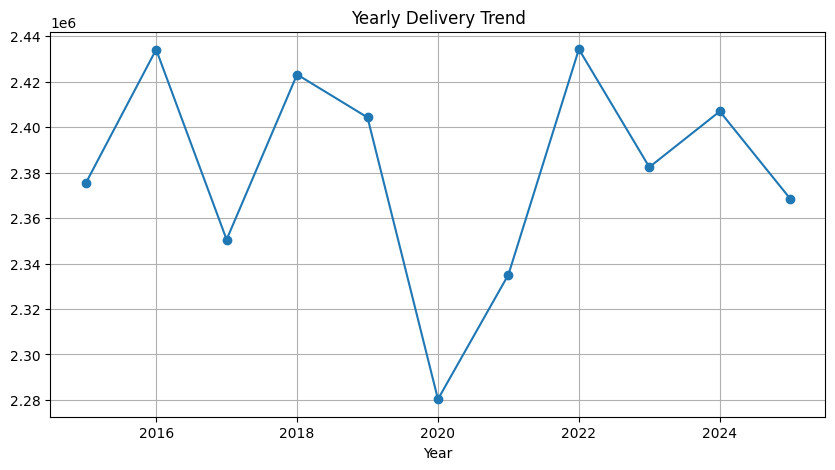

In [11]:

yearly = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))
yearly.plot(marker='o')
plt.title('Yearly Delivery Trend')
plt.grid(True)
plt.show()


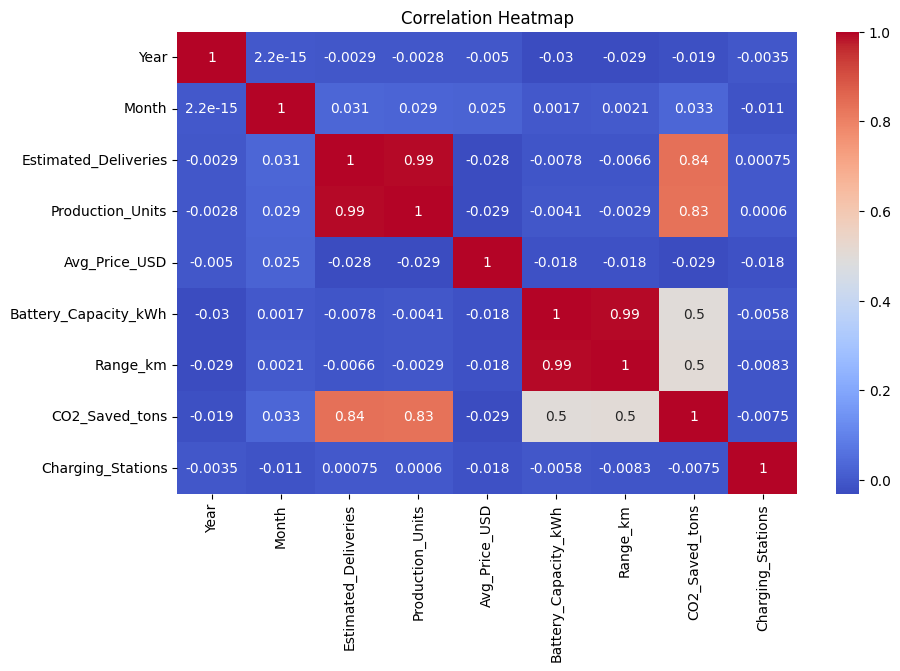

In [12]:

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## 4. Feature Engineering

In [13]:

df['Production_Efficiency'] = (
    df['Estimated_Deliveries'] / df['Production_Units']
)

df['CO2_per_Production'] = (
    df['CO2_Saved_tons'] / df['Production_Units']
)

df['Price_Category'] = pd.qcut(
    df['Avg_Price_USD'],
    q=3,
    labels=['Low','Medium','High']
)

df['Prev_Month_Delivery'] = (
    df['Estimated_Deliveries'].shift(1)
)

df['Prev_Month_Delivery'].fillna(
    df['Prev_Month_Delivery'].median(),
    inplace=True
)

display(df.head())


/tmp/ipykernel_1350/1452827973.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Prev_Month_Delivery'].fillna(


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Production_Efficiency,CO2_per_Production,Price_Category,Prev_Month_Delivery
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,0.984600,0.103974,Medium,9860.0
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,0.911864,0.059909,Low,17646.0
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,0.915334,0.065904,High,3797.0
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,0.896594,0.095756,Medium,8411.0
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,0.914087,0.090632,High,6555.0


## 5. Encoding Categorical Variables

In [14]:

categorical_cols = ['Region','Model','Source_Type','Price_Category']

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Production_Efficiency,CO2_per_Production,Price_Category,Prev_Month_Delivery
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,0.984600,0.103974,2,9860.0
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,0.911864,0.059909,1,17646.0
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,0.915334,0.065904,0,3797.0
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,0.896594,0.095756,2,8411.0
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,0.914087,0.090632,0,6555.0


## 6. Prepare Data for Machine Learning

In [15]:

X = df.drop('Estimated_Deliveries', axis=1)
y = df['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)


(2112, 15) (528, 15)


## 7. Linear Regression Model

In [16]:

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, pred_lr))
print("MAE:", mean_absolute_error(y_test, pred_lr))


R2 Score: 0.9984211245192132
MAE: 108.9249943765857


## 8. Ridge Regression

In [17]:

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

pred_ridge = ridge.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, pred_ridge))
print("MAE:", mean_absolute_error(y_test, pred_ridge))


R2 Score: 0.998412322178788
MAE: 108.92653784448687


## 9. Lasso Regression

In [18]:

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

pred_lasso = lasso.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, pred_lasso))
print("MAE:", mean_absolute_error(y_test, pred_lasso))


R2 Score: 0.9984242295657694
MAE: 108.72736821018685


## 10. Hyperparameter Tuning using GridSearchCV

In [19]:

params = {'alpha':[0.01,0.1,1,10,100]}

grid = GridSearchCV(
    Ridge(),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train_scaled, y_train)

print("Best Alpha:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Alpha: {'alpha': 0.1}
Best Score: 0.9984130464223095


## 11. Cross Validation

In [20]:

scores = cross_val_score(
    LinearRegression(),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("Average CV Score:", scores.mean())


Average CV Score: 0.9984128768395417


## 12. Time Series Forecasting

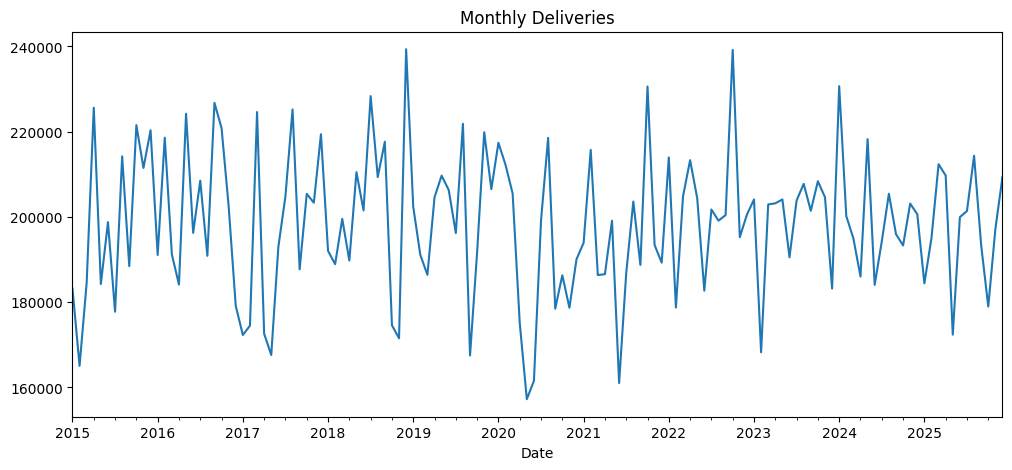

In [21]:

df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-01'
)

ts = df.groupby('Date')['Estimated_Deliveries'].sum()

plt.figure(figsize=(12,5))
ts.plot()
plt.title('Monthly Deliveries')
plt.show()


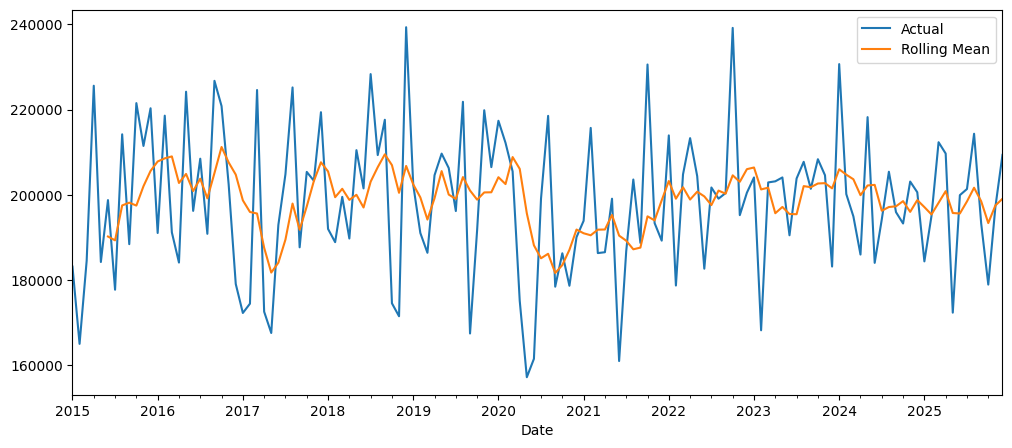

In [22]:

rolling_mean = ts.rolling(window=6).mean()

plt.figure(figsize=(12,5))
ts.plot(label='Actual')
rolling_mean.plot(label='Rolling Mean')
plt.legend()
plt.show()


## 13. Model Comparison

In [23]:

results = pd.DataFrame({
    'Model':['Linear Regression','Ridge','Lasso'],
    'R2':[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_ridge),
        r2_score(y_test,pred_lasso)
    ],
    'MAE':[
        mean_absolute_error(y_test,pred_lr),
        mean_absolute_error(y_test,pred_ridge),
        mean_absolute_error(y_test,pred_lasso)
    ]
})

results.sort_values('R2', ascending=False)


,Model,R2,MAE
2,Lasso,0.998424,108.727368
0,Linear Regression,0.998421,108.924994
1,Ridge,0.998412,108.926538



# Conclusion

This project successfully demonstrates an end-to-end ML pipeline:

- Data Cleaning and Preprocessing
- Exploratory Data Analysis
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Cross Validation
- Time Series Forecasting

The best model can be selected using the highest R² score and lowest MAE.
